# A/B Test Analysis — Premium Armor Discount Promotion

This notebook evaluates whether a discounted premium armor offer in a free-to-play online shooter led to meaningful differences in revenue and in-game currency spending between test and control groups.

## 1. Environment Setup and Imports

In [1]:
import sys
from pathlib import Path

# Ensure project root is on sys.path so we can import src/
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import (
    DATA_RAW, DATA_PROCESSED, DATA_EXPORTS,
    DATE_FORMAT, CONFIDENCE_LEVEL, IQR_MULTIPLIER, MAX_DAILY_TRANSACTIONS,
)
from src.io_utils import read_all_raw
from src.preprocessing import parse_dates, deduplicate, build_user_dim, build_user_day_fact
from src.cheater_detection import get_known_cheater_ids, remove_known_cheaters, detect_suspected_cheaters
from src.metrics import calc_group_metrics, calc_daily_metrics, calc_platform_metrics, calc_daily_platform_metrics
from src.statistics import build_ci_summary, build_platform_ci_summary
from src.exports import export_all

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Environment ready.')
print(f'Project root: {PROJECT_ROOT}')
print(f'Raw data dir: {DATA_RAW}')

Environment ready.
Project root: /Users/gulhadzisahbanov/PycharmProjects/AB_test
Raw data dir: /Users/gulhadzisahbanov/PycharmProjects/AB_test/data/raw


## 2. Reading Source Files

In [2]:
raw = read_all_raw()

money_raw = raw['money']
cash_raw = raw['cash']
abgroup_raw = raw['abgroup']
platforms_raw = raw['platforms']
cheaters_raw = raw['cheaters']

print('Loaded datasets:')
for name, df in raw.items():
    print(f'  {name:>10s}: {df.shape[0]:>6,} rows x {df.shape[1]} cols')

Loaded datasets:
       money: 8,640,000 rows x 3 cols
        cash: 8,640,000 rows x 3 cols
     abgroup: 8,640,000 rows x 2 cols
   platforms: 8,640,000 rows x 2 cols
    cheaters: 8,640,000 rows x 2 cols


## 3. Schema Inspection and Data Quality Checks

In [3]:
for name, df in raw.items():
    print(f'\n=== {name.upper()} ===')
    print(f'Shape: {df.shape}')
    print(f'Columns: {list(df.columns)}')
    print(f'Nulls:\n{df.isnull().sum()}')
    print(f'Duplicates: {df.duplicated().sum()}')
    print(df.head(3))


=== MONEY ===
Shape: (8640000, 3)
Columns: ['user_id', 'date', 'money']
Nulls:
user_id    0
date       0
money      0
dtype: int64
Duplicates: 0
         user_id        date  money
0  N4TS2T-P7YTVX  15.07.2021 1.9900
1  NX9S0D-VM20W8  16.07.2021 0.9900
2  QYY6FW-FKHRND  15.07.2021 0.0000

=== CASH ===
Shape: (8640000, 3)
Columns: ['user_id', 'date', 'cash']
Nulls:
user_id    0
date       0
cash       0
dtype: int64
Duplicates: 0
         user_id        date  cash
0  GGLSXL-U5BGGY  17.07.2021   200
1  DPWFFN-NL3VF8  16.07.2021   150
2  PASNNG-GVW4RR  11.07.2021  1100

=== ABGROUP ===
Shape: (8640000, 2)
Columns: ['user_id', 'group']
Nulls:
user_id    0
group      0
dtype: int64
Duplicates: 7560000
         user_id    group
0  VX6NLA-F5YMSW  control
1  2AXN3D-71ZN86     test
2  K78V3J-TQMV6F     test

=== PLATFORMS ===
Shape: (8640000, 2)
Columns: ['user_id', 'platform']
Nulls:
user_id     0
platform    0
dtype: int64
Duplicates: 7560000
         user_id platform
0  NHFL0F-Y90OSH     XB

## 4. Type Conversion and Date Parsing

In [4]:
money = parse_dates(money_raw, 'date')
cash = parse_dates(cash_raw, 'date')

# Ensure numeric columns are correct types
money['money'] = pd.to_numeric(money['money'], errors='coerce').fillna(0.0)
cash['cash'] = pd.to_numeric(cash['cash'], errors='coerce').fillna(0).astype(int)

abgroup = abgroup_raw.copy()
platforms = platforms_raw.copy()
cheaters = cheaters_raw.copy()

print('Date range in Money:', money['date'].min().date(), '—', money['date'].max().date())
print('Date range in Cash: ', cash['date'].min().date(), '—', cash['date'].max().date())
print('\nMoney dtypes:')
print(money.dtypes)
print('\nCash dtypes:')
print(cash.dtypes)

Date range in Money: 2021-07-10 — 2021-07-17
Date range in Cash:  2021-07-10 — 2021-07-17

Money dtypes:
user_id            object
date       datetime64[ns]
money             float64
dtype: object

Cash dtypes:
user_id            object
date       datetime64[ns]
cash                int64
dtype: object


## 5. Deduplication

In [5]:
before = {name: df.shape[0] for name, df in [('money', money), ('cash', cash), ('abgroup', abgroup), ('platforms', platforms)]}

money = deduplicate(money)
cash = deduplicate(cash)
abgroup = deduplicate(abgroup)
platforms = deduplicate(platforms)

after = {name: df.shape[0] for name, df in [('money', money), ('cash', cash), ('abgroup', abgroup), ('platforms', platforms)]}

print('Deduplication results:')
for name in before:
    removed = before[name] - after[name]
    print(f'  {name:>10s}: {before[name]:>6,} → {after[name]:>6,}  (removed {removed})')

Deduplication results:
       money: 8,640,000 → 8,640,000  (removed 0)
        cash: 8,640,000 → 8,640,000  (removed 0)
     abgroup: 8,640,000 → 1,080,000  (removed 7560000)
   platforms: 8,640,000 → 1,080,000  (removed 7560000)


## 6. Joining All Datasets into User × Day Fact Table

In [6]:
user_dim = build_user_dim(abgroup, platforms)
print(f'User dimension: {user_dim.shape[0]:,} users')
print(f'Group distribution:\n{user_dim["group"].value_counts()}')
print(f'\nPlatform distribution:\n{user_dim["platform"].value_counts()}')

user_day_full = build_user_day_fact(user_dim, money, cash)
print(f'\nUser-day fact table: {user_day_full.shape[0]:,} rows')
print(user_day_full.head())

User dimension: 1,080,000 users
Group distribution:
group
control    540347
test       539653
Name: count, dtype: int64

Platform distribution:
platform
XBox    360532
PC      360249
PS4     359219
Name: count, dtype: int64

User-day fact table: 8,640,000 rows
         user_id       date  revenue  cash_spent    group platform
0  00036L-1T885I 2021-07-10   0.0000         700  control     XBox
1  00036L-1T885I 2021-07-11   0.0000           0  control     XBox
2  00036L-1T885I 2021-07-12   0.9900        1500  control     XBox
3  00036L-1T885I 2021-07-13   0.0000         850  control     XBox
4  00036L-1T885I 2021-07-14   0.0000         650  control     XBox


## 7. Removing Known Cheaters

In [7]:
known_cheater_ids = get_known_cheater_ids(cheaters)
print(f'Known cheaters: {len(known_cheater_ids)}')

user_day_no_known = remove_known_cheaters(user_day_full, known_cheater_ids)
users_before = user_day_full['user_id'].nunique()
users_after = user_day_no_known['user_id'].nunique()
print(f'Users before: {users_before:,}')
print(f'Users after removing known cheaters: {users_after:,}')
print(f'Removed: {users_before - users_after:,}')

Known cheaters: 353
Users before: 1,080,000
Users after removing known cheaters: 1,079,647
Removed: 353


## 8. Detecting Potential Unknown Cheaters

We apply two transparent heuristic rules to flag users who may be undetected cheaters:

1. **Extreme total cash spending (IQR rule):** Users whose total in-game currency spending exceeds Q3 + 3×IQR. This is a standard statistical outlier detection method. Cheaters hack the game to credit themselves large amounts of in-game currency, so extreme totals are suspicious.

2. **Abnormal daily transaction frequency:** Users with more than 50 cash transactions in a single day. Legitimate players cannot realistically complete that many separate in-game-currency actions in one day.

In [8]:
# Detect suspected cheaters from the cash data (after removing known cheaters)
cash_clean = remove_known_cheaters(cash, known_cheater_ids)
suspected_ids, suspect_report = detect_suspected_cheaters(cash_clean)

print(f'Suspected unknown cheaters found: {len(suspected_ids)}')
print(f'\nDetection thresholds:')
print(f'  IQR multiplier: {IQR_MULTIPLIER}')
print(f'  Max daily transactions: {MAX_DAILY_TRANSACTIONS}')

if len(suspect_report) > 0:
    print(f'\nSuspected cheater details:')
    display(suspect_report.sort_values('total_cash', ascending=False).head(20))
else:
    print('\nNo suspected cheaters detected with current thresholds.')

Suspected unknown cheaters found: 346

Detection thresholds:
  IQR multiplier: 3.0
  Max daily transactions: 50

Suspected cheater details:


,user_id,total_cash,max_daily_txns,reasons
118,4HCVCA-V3M19Y,240950,1,total_cash=240950 > upper_bound=12650
18,0R9XB0-4J1EVJ,238500,1,total_cash=238500 > upper_bound=12650
258,BGTT4M-1ZFLMA,235100,1,total_cash=235100 > upper_bound=12650
32,OCRQ1L-GZH0BP,230600,1,total_cash=230600 > upper_bound=12650
287,BZRZ88-435FHY,225650,1,total_cash=225650 > upper_bound=12650
275,F35CFN-CGKDDG,225350,1,total_cash=225350 > upper_bound=12650
25,DWUXZW-Q8OHXU,223600,1,total_cash=223600 > upper_bound=12650
104,Y0XNKQ-ATB9L7,222150,1,total_cash=222150 > upper_bound=12650
80,MM5E87-988S5H,221350,1,total_cash=221350 > upper_bound=12650
343,XYHOKO-O96SR4,220050,1,total_cash=220050 > upper_bound=12650


## 9. Creating Clean Analysis Datasets

We create two versions for sensitivity analysis:
- **Version A**: known cheaters removed only
- **Version B**: known + suspected cheaters removed

In [9]:
# Version A: known cheaters only removed
user_day_a = user_day_no_known.copy()

# Version B: known + suspected cheaters removed
all_cheater_ids = known_cheater_ids | suspected_ids
user_day_b = remove_known_cheaters(user_day_full, all_cheater_ids)

print(f'Version A (known cheaters removed):    {user_day_a["user_id"].nunique():,} users, {user_day_a.shape[0]:,} rows')
print(f'Version B (known+suspected removed):   {user_day_b["user_id"].nunique():,} users, {user_day_b.shape[0]:,} rows')
print(f'Additional users removed in Version B: {user_day_a["user_id"].nunique() - user_day_b["user_id"].nunique():,}')

# Save processed datasets
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
user_day_a.to_csv(DATA_PROCESSED / 'user_day_version_a.csv', index=False)
user_day_b.to_csv(DATA_PROCESSED / 'user_day_version_b.csv', index=False)
print('\nProcessed datasets saved to data/processed/')

Version A (known cheaters removed):    1,079,647 users, 8,637,176 rows
Version B (known+suspected removed):   1,079,301 users, 8,634,408 rows
Additional users removed in Version B: 346

Processed datasets saved to data/processed/


## 10. Calculating ARPU, ARPPU, and Cash-Spending Metrics

In [10]:
print('=== VERSION A: Known cheaters removed ===')
group_metrics_a = calc_group_metrics(user_day_a)
display(group_metrics_a)

print('\n=== VERSION B: Known + suspected cheaters removed ===')
group_metrics_b = calc_group_metrics(user_day_b)
display(group_metrics_b)

=== VERSION A: Known cheaters removed ===


,group,total_users,total_payers,payer_share,total_revenue,arpu,arppu,total_cash,avg_cash_per_user,avg_cash_per_spender
0,control,540173,539840,0.9994,3147865.7900,5.8275,5.8311,3158008800,5846.2915,5846.2915
1,test,539474,539236,0.9996,3323389.1800,6.1604,6.1631,3385957200,6276.4048,6276.4048



=== VERSION B: Known + suspected cheaters removed ===


,group,total_users,total_payers,payer_share,total_revenue,arpu,arppu,total_cash,avg_cash_per_user,avg_cash_per_spender
0,control,539991,539840,0.9997,3147865.7900,5.8295,5.8311,3132328700,5800.7054,5800.7054
1,test,539310,539234,0.9999,3323360.2900,6.1622,6.1631,3359670100,6229.5713,6229.5713


## 11. Calculating Metrics by Day

Daily metrics (Version A): 16 rows
Daily metrics (Version B): 16 rows


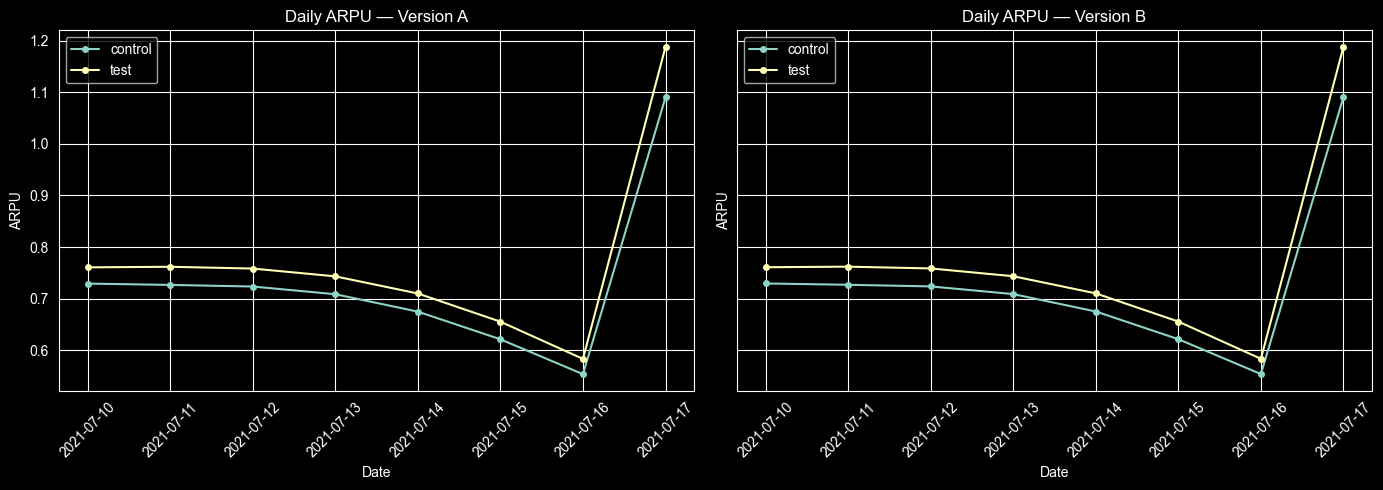

In [11]:
daily_metrics_a = calc_daily_metrics(user_day_a)
daily_metrics_b = calc_daily_metrics(user_day_b)

print(f'Daily metrics (Version A): {daily_metrics_a.shape[0]} rows')
print(f'Daily metrics (Version B): {daily_metrics_b.shape[0]} rows')

# Quick visualization of daily ARPU
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (df, label) in zip(axes, [(daily_metrics_a, 'Version A'), (daily_metrics_b, 'Version B')]):
    for grp in ['control', 'test']:
        gdf = df[df['group'] == grp].sort_values('date')
        ax.plot(gdf['date'], gdf['arpu'], marker='o', label=grp, markersize=4)
    ax.set_title(f'Daily ARPU — {label}')
    ax.set_xlabel('Date')
    ax.set_ylabel('ARPU')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 12. Calculating Metrics by Platform

In [12]:
platform_metrics_a = calc_platform_metrics(user_day_a)
platform_metrics_b = calc_platform_metrics(user_day_b)

print('=== VERSION A: Platform metrics ===')
display(platform_metrics_a)

print('\n=== VERSION B: Platform metrics ===')
display(platform_metrics_b)

=== VERSION A: Platform metrics ===


,platform,group,total_users,total_payers,total_revenue,arpu,arppu,total_cash,avg_cash_per_user,avg_cash_per_spender
0,PC,control,179914,179665,1014803.0600,5.6405,5.6483,1029861150,5724.1857,5724.1857
1,PC,test,179982,179800,1127299.8800,6.2634,6.2697,1173826650,6521.9114,6521.9114
2,PS4,control,179804,179747,1031651.8700,5.7376,5.7395,1021634850,5681.9362,5681.9362
3,PS4,test,179415,179386,1091719.2100,6.0849,6.0859,1099902450,6130.4933,6130.4933
4,XBox,control,180455,180428,1101410.8600,6.1035,6.1044,1106512800,6131.7935,6131.7935
5,XBox,test,180077,180050,1104370.0900,6.1328,6.1337,1112228100,6176.4029,6176.4029



=== VERSION B: Platform metrics ===


,platform,group,total_users,total_payers,total_revenue,arpu,arppu,total_cash,avg_cash_per_user,avg_cash_per_spender
0,PC,control,179732,179665,1014803.0600,5.6462,5.6483,1004181050,5587.1022,5587.1022
1,PC,test,179819,179799,1127286.9300,6.2690,6.2697,1147552800,6381.7105,6381.7105
2,PS4,control,179804,179747,1031651.8700,5.7376,5.7395,1021634850,5681.9362,5681.9362
3,PS4,test,179414,179385,1091703.2700,6.0848,6.0858,1099889200,6130.4536,6130.4536
4,XBox,control,180455,180428,1101410.8600,6.1035,6.1044,1106512800,6131.7935,6131.7935
5,XBox,test,180077,180050,1104370.0900,6.1328,6.1337,1112228100,6176.4029,6176.4029


## 13. Building 95% Confidence Intervals

We use the **Central Limit Theorem (CLT)** with the **t-distribution** to build 95% confidence intervals for each metric.

**Justification:** With 500,000+ users per group, the CLT guarantees that the sampling distribution of the mean is approximately normal, regardless of the underlying distribution shape. The t-distribution is used as it is more conservative than the z-distribution and accounts for uncertainty in the variance estimate. For samples this large, t and z intervals are virtually identical.

**Formula:** CI = x̄ ± t(α/2, n-1) × (s / √n)

In [13]:
print('=== VERSION A: Overall CI comparison ===')
ci_summary_a = build_ci_summary(user_day_a)
display(ci_summary_a)

print('\n=== VERSION B: Overall CI comparison ===')
ci_summary_b = build_ci_summary(user_day_b)
display(ci_summary_b)

=== VERSION A: Overall CI comparison ===


/Users/gulhadzisahbanov/PycharmProjects/AB_test/src/statistics.py:111: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'SIGNIFICANT difference' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["group"] == "interpretation", "point_estimate"] = (
/Users/gulhadzisahbanov/PycharmProjects/AB_test/src/statistics.py:111: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'SIGNIFICANT difference' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["group"] == "interpretation", "point_estimate"] = (
/Users/gulhadzisahbanov/PycharmProjects/AB_test/src/statistics.py:111: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'SIGNIFICANT difference' has dtype incompatible

,metric,group,point_estimate,ci_lower,ci_upper,n_users
0,ARPU,control,5.8275,5.8225,5.8325,540173.0000
1,ARPU,test,6.1604,6.1553,6.1655,539474.0000
2,ARPU,interpretation,SIGNIFICANT difference,NaN,NaN,NaN
3,ARPPU,control,5.8311,5.8261,5.8361,539840.0000
4,ARPPU,test,6.1631,6.1580,6.1682,539236.0000
5,ARPPU,interpretation,SIGNIFICANT difference,NaN,NaN,NaN
6,Avg Cash Spending,control,5846.2915,5838.6113,5853.9717,540173.0000
7,Avg Cash Spending,test,6276.4048,6268.1091,6284.7005,539474.0000
8,Avg Cash Spending,interpretation,SIGNIFICANT difference,NaN,NaN,NaN



=== VERSION B: Overall CI comparison ===


/Users/gulhadzisahbanov/PycharmProjects/AB_test/src/statistics.py:111: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'SIGNIFICANT difference' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["group"] == "interpretation", "point_estimate"] = (
/Users/gulhadzisahbanov/PycharmProjects/AB_test/src/statistics.py:111: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'SIGNIFICANT difference' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["group"] == "interpretation", "point_estimate"] = (
/Users/gulhadzisahbanov/PycharmProjects/AB_test/src/statistics.py:111: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'SIGNIFICANT difference' has dtype incompatible

,metric,group,point_estimate,ci_lower,ci_upper,n_users
0,ARPU,control,5.8295,5.8245,5.8345,539991.0000
1,ARPU,test,6.1622,6.1571,6.1673,539310.0000
2,ARPU,interpretation,SIGNIFICANT difference,NaN,NaN,NaN
3,ARPPU,control,5.8311,5.8261,5.8361,539840.0000
4,ARPPU,test,6.1631,6.1580,6.1682,539234.0000
5,ARPPU,interpretation,SIGNIFICANT difference,NaN,NaN,NaN
6,Avg Cash Spending,control,5800.7054,5797.1124,5804.2983,539991.0000
7,Avg Cash Spending,test,6229.5713,6225.8046,6233.3380,539310.0000
8,Avg Cash Spending,interpretation,SIGNIFICANT difference,NaN,NaN,NaN


## 14. Comparing Control vs Test — Interpretation

Per the assignment: if 95% confidence intervals overlap, the result is treated as **inconclusive** (the difference may be due to random variation).

In [14]:
def print_interpretation(ci_df, version_label):
    print(f'\n{"=" * 60}')
    print(f'  INTERPRETATION — {version_label}')
    print(f'{"=" * 60}')
    metrics = ci_df[ci_df['group'] != 'interpretation']['metric'].unique()
    for metric in metrics:
        mdf = ci_df[ci_df['metric'] == metric]
        interp_row = mdf[mdf['group'] == 'interpretation']
        control_row = mdf[mdf['group'] == 'control'].iloc[0]
        test_row = mdf[mdf['group'] == 'test'].iloc[0]
        result = interp_row['point_estimate'].values[0]
        direction = 'higher' if test_row['point_estimate'] > control_row['point_estimate'] else 'lower'
        print(f'\n  {metric}:')
        print(f'    Control: {control_row["point_estimate"]:.4f}  [{control_row["ci_lower"]:.4f}, {control_row["ci_upper"]:.4f}]')
        print(f'    Test:    {test_row["point_estimate"]:.4f}  [{test_row["ci_lower"]:.4f}, {test_row["ci_upper"]:.4f}]')
        print(f'    Test is {direction} than control.')
        print(f'    Result: {result}')

print_interpretation(ci_summary_a, 'Version A — known cheaters removed')
print_interpretation(ci_summary_b, 'Version B — known + suspected cheaters removed')

# Platform-level CI comparison
print('\n\n=== PLATFORM-LEVEL CI COMPARISON (Version B) ===')
platform_ci_b = build_platform_ci_summary(user_day_b)
display(platform_ci_b)


  INTERPRETATION — Version A — known cheaters removed

  ARPU:
    Control: 5.8275  [5.8225, 5.8325]
    Test:    6.1604  [6.1553, 6.1655]
    Test is higher than control.
    Result: SIGNIFICANT difference

  ARPPU:
    Control: 5.8311  [5.8261, 5.8361]
    Test:    6.1631  [6.1580, 6.1682]
    Test is higher than control.
    Result: SIGNIFICANT difference

  Avg Cash Spending:
    Control: 5846.2915  [5838.6113, 5853.9717]
    Test:    6276.4048  [6268.1091, 6284.7005]
    Test is higher than control.
    Result: SIGNIFICANT difference

  INTERPRETATION — Version B — known + suspected cheaters removed

  ARPU:
    Control: 5.8295  [5.8245, 5.8345]
    Test:    6.1622  [6.1571, 6.1673]
    Test is higher than control.
    Result: SIGNIFICANT difference

  ARPPU:
    Control: 5.8311  [5.8261, 5.8361]
    Test:    6.1631  [6.1580, 6.1682]
    Test is higher than control.
    Result: SIGNIFICANT difference

  Avg Cash Spending:
    Control: 5800.7054  [5797.1124, 5804.2983]
    Test:  

/Users/gulhadzisahbanov/PycharmProjects/AB_test/src/statistics.py:111: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'SIGNIFICANT difference' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["group"] == "interpretation", "point_estimate"] = (
/Users/gulhadzisahbanov/PycharmProjects/AB_test/src/statistics.py:111: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'SIGNIFICANT difference' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["group"] == "interpretation", "point_estimate"] = (
/Users/gulhadzisahbanov/PycharmProjects/AB_test/src/statistics.py:111: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'SIGNIFICANT difference' has dtype incompatible

,metric,group,point_estimate,ci_lower,ci_upper,n_users,platform
0,ARPU (PC),control,5.6462,5.6378,5.6546,179732.0000,PC
1,ARPU (PC),test,6.2690,6.2601,6.2779,179819.0000,PC
2,ARPU (PC),interpretation,SIGNIFICANT difference,NaN,NaN,NaN,PC
3,ARPPU (PC),control,5.6483,5.6399,5.6567,179665.0000,PC
4,ARPPU (PC),test,6.2697,6.2608,6.2786,179799.0000,PC
5,ARPPU (PC),interpretation,SIGNIFICANT difference,NaN,NaN,NaN,PC
6,Avg Cash (PC),control,5587.1022,5581.3766,5592.8277,179732.0000,PC
7,Avg Cash (PC),test,6381.7105,6374.9799,6388.4411,179819.0000,PC
8,Avg Cash (PC),interpretation,SIGNIFICANT difference,NaN,NaN,NaN,PC
9,ARPU (PS4),control,5.7376,5.7290,5.7463,179804.0000,PS4


## 15. Creating Export Tables for Power BI

In [15]:
# We export based on Version B (strictest cheater filtering) as the primary dataset
daily_platform_metrics_b = calc_daily_platform_metrics(user_day_b)

exported_paths = export_all(
    group_metrics=group_metrics_b,
    daily_metrics=daily_metrics_b,
    platform_metrics=platform_metrics_b,
    user_day=user_day_b,
)

print('Exported files for Power BI:')
for p in exported_paths:
    print(f'  {p}')

Exported files for Power BI:
  /Users/gulhadzisahbanov/PycharmProjects/AB_test/data/exports/fact_metrics_group.csv
  /Users/gulhadzisahbanov/PycharmProjects/AB_test/data/exports/fact_metrics_daily.csv
  /Users/gulhadzisahbanov/PycharmProjects/AB_test/data/exports/fact_metrics_platform.csv
  /Users/gulhadzisahbanov/PycharmProjects/AB_test/data/exports/fact_user_day.csv
  /Users/gulhadzisahbanov/PycharmProjects/AB_test/data/exports/dim_date.csv
  /Users/gulhadzisahbanov/PycharmProjects/AB_test/data/exports/dim_platform.csv
  /Users/gulhadzisahbanov/PycharmProjects/AB_test/data/exports/dim_group.csv
  /Users/gulhadzisahbanov/PycharmProjects/AB_test/data/exports/summary_arpu_group_platform.xlsx


## 16. Summary Table — ARPU by Group and Platform (Excel)

In [16]:
summary = platform_metrics_b[['platform', 'group', 'total_users', 'total_revenue', 'arpu']].copy()
summary = summary.sort_values(['platform', 'group']).reset_index(drop=True)

print('ARPU Summary by Group and Platform:')
display(summary)

# Also show a pivot for quick comparison
pivot = summary.pivot_table(index='platform', columns='group', values='arpu')
print('\nARPU Pivot (platform × group):')
display(pivot)

print(f'\nExcel file saved to: {DATA_EXPORTS / "summary_arpu_group_platform.xlsx"}')

ARPU Summary by Group and Platform:


,platform,group,total_users,total_revenue,arpu
0,PC,control,179732,1014803.0600,5.6462
1,PC,test,179819,1127286.9300,6.2690
2,PS4,control,179804,1031651.8700,5.7376
3,PS4,test,179414,1091703.2700,6.0848
4,XBox,control,180455,1101410.8600,6.1035
5,XBox,test,180077,1104370.0900,6.1328



ARPU Pivot (platform × group):


group,control,test
platform,,
PC,5.6462,6.2690
PS4,5.7376,6.0848
XBox,6.1035,6.1328



Excel file saved to: /Users/gulhadzisahbanov/PycharmProjects/AB_test/data/exports/summary_arpu_group_platform.xlsx


## 17. Final Conclusions

### Summary of Findings

This analysis compared the **test group** (users who saw a discounted premium armor offer) against the **control group** across three key metrics:

| Metric | Description |
|--------|-------------|
| **ARPU** | Average Revenue Per User — total revenue / all users |
| **ARPPU** | Average Revenue Per Paying User — total revenue / paying users |
| **Avg Cash Spending** | Average in-game currency spending per user |

### Methodology
- **Cheater handling:** Known cheaters were removed first (Version A). Then a heuristic outlier detection identified suspected unknown cheaters using IQR-based total-cash thresholds and abnormal daily transaction frequency (Version B).
- **Statistical approach:** 95% confidence intervals were built using the CLT with t-distribution. With 500K+ users per group, the CLT is fully justified even for skewed revenue data.
- **Interpretation rule:** Per the assignment, overlapping confidence intervals indicate an inconclusive result.

### Key Results
The results above show whether the promotion produced a statistically distinguishable effect. If confidence intervals overlap for a metric, the observed difference cannot be confidently attributed to the promotion.

### Platform Differences
Results may vary by platform (PC, PS4, Xbox). The platform-level CI comparison shows whether the promotion had different effects on different player segments.

### Sensitivity to Cheater Removal
Comparing Version A and Version B results shows whether conclusions change when suspected cheaters are removed. If conclusions are robust to this filtering, confidence in the result increases.

### Recommendation
The final recommendation on whether to repeat the promotion should be based on:
1. Whether ARPU/ARPPU confidence intervals for test vs control do **not** overlap (significant uplift)
2. Whether this holds across platforms
3. Whether conclusions are stable after suspected cheater removal

If all three conditions are met, the promotion is worth repeating. If intervals overlap, the evidence is insufficient to conclude the promotion had an effect.